# WIE2003 Introduction to Data Science
# Data-Driven Property Price Analysis and Classification System

## Background


Kuala Lumpur, the heart of Malaysia’s economic landscape, has recently demonstrated significant market volatility, with a 12.07% surge in median property prices and a 5.06% increase in median price per square foot (psf) recorded throughout 2025 [Property Genie, 2025]. Despite this growth, the dream of homeownership remains elusive for many. Prospective buyers face a "triad of hurdles": the inherent complexity of the Malaysian property market, post-pandemic economic shifts, and the erratic nature of global inflationary pressures [Siti Nur Hadi, 2024].

A critical limitation of current market analysis is its heavy reliance on generalized broad averages, which often mask lucrative hyper-local opportunities. There is a demonstrable need for a localized, automated Decision Support System (DSS) that utilizes machine learning to categorize and navigate this complex residential landscape. This project, titled "Data-Driven Property Price Analysis," leverages raw government transaction data from the National Property Information Centre (NAPIC) to extract actionable market insights. By developing a predictive classification model, this study aims to empower stakeholders with high-granularity data, transforming raw historical transactions into a robust tool for informed real estate decision-making.

Reference:

https://www.propertygenie.com.my/transaction-and-statistics/residential/wp-kuala-lumpur#google_vignette
https://bridgeproperties.com.my/guides/1761084535846-buying


## Data Source

The data used in this project is obtained from Malaysia Government official portal - National Property Information Centre (NAPIC). The dataset from the portal is a open data. This dataset consists of essential variables such as Property Type, District (Mukim), Transaction Date (Year Month), Land/Parcel Area, Main Floor Area, Unit Level and Transaction Price, where these variables would be used in the following Data Science Project for data analysis as well as to develop a data product.


**Link to dataset:** https://napic.jpph.gov.my/en/open-sales-data?category=36&id=241

# 1.0 Initial Data Exploration

This section will load the dataset and do brief investigation on the dataset.
### Data Dictionary (Column Descriptions)
Based on the raw data, our dataset contains the following columns:
* **Property Type:** The classification of the property (e.g., Terrace, Bungalow, Condominium).
* **District:** The administrative district where the property is located.
* **Mukim:** The sub-district/township of the property.
* **Scheme Name/Area:** The specific housing scheme or neighborhood.
* **Road Name:** The street address of the property.
* **Month, Year of Transaction Date:** The date the property was sold.
* **Tenure:** The ownership type (e.g., Freehold, Leasehold).
* **Land/Parcel Area:** The size of the land the property sits on.
* **Unit (1):** The measurement unit for the Land Area.
* **Main Floor Area:** The built-up size of the building itself.
* **Unit (2):** The measurement unit for the Floor Area.
* **Unit Level:** The floor level of the property (applicable for strata titles like apartments).
* **Transaction Price:** The final sold price of the property in Ringgit Malaysia (RM).

**Import Libraries**

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns

**Mount dataset to drive**

In [2]:
# Mount dataset to drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load dataset into dataframe**

In [3]:
# Path to your CSV file
csv_path = '/content/drive/MyDrive/IDS Project/Dataset/Property.csv'

# Load dataset
df = pd.read_csv(csv_path, encoding='utf-16', sep='\t')

# Clean up column names to remove accidental whitespaces
df.columns = df.columns.str.strip()

# Display first few rows
df.head()

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,March 2024,Freehold,374.00,sq.m,106,sq.m,,"RM470,000.00",NaN
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,May 2023,Leasehold,234.00,sq.m,67,sq.m,,"RM483,000.00",NaN
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM359,000.00",NaN
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM435,000.00",NaN
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,297.00,sq.m,118,sq.m,,"RM373,000.00",NaN


**Inspecting dataset**

rows, columns, metadata, datatypes etc

In [4]:
# Observe the shape (rows and columns)
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")

# Observe metadata and data types
print("=== Dataset Info ===")
df.info()

# Observe basic statistical summaries for numerical columns
print("\n=== Statistical Summary ===")
display(df.describe(include='all'))

Dataset Shape: 410959 rows and 14 columns

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410959 entries, 0 to 410958
Data columns (total 14 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Property Type                    410959 non-null  object 
 1   District                         410959 non-null  object 
 2   Mukim                            410959 non-null  object 
 3   Scheme Name/Area                 410959 non-null  object 
 4   Road Name                        410959 non-null  object 
 5   Month, Year of Transaction Date  410959 non-null  object 
 6   Tenure                           410959 non-null  object 
 7   Land/Parcel Area                 410958 non-null  object 
 8   Unit                             410959 non-null  object 
 9   Main Floor Area                  410959 non-null  object 
 10  Unit                             410959 non-null  object 
 11  U

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
count,410959,410959,410959,410959,410959,410959,410959,410958,410959,410959,410959,410959,410959,0.0
unique,11,127,1340,23496,120216,60,2,17612,1,825,2,134,3388,NaN
top,2 - 2 1/2 Storey Terraced,Johor Bahru,Pulai,BDR PUTRA,,December 2021,Freehold,130.00,sq.m,-,sq.m,,"RM250,000.00",NaN
freq,117403,45701,17305,1724,106462,15084,272746,28271,410959,106460,304505,304482,9312,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Check for null values, duplicate columns, and unique categories**

In [5]:
print("=== Null Values Per Column ===")
print(df.isnull().sum())

print("\n=== Duplicate Column Names ===")
duplicates = df.columns[df.columns.duplicated()]
print(f"Duplicate columns: {duplicates.tolist()}")

print("\n=== Unique Values in Categorical Columns ===")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

=== Null Values Per Column ===
Property Type                           0
District                                0
Mukim                                   0
Scheme Name/Area                        0
Road Name                               0
Month, Year of Transaction Date         0
Tenure                                  0
Land/Parcel Area                        1
Unit                                    0
Main Floor Area                         0
Unit                                    0
Unit Level                              0
Transaction Price                       0
Unnamed: 13                        410959
dtype: int64

=== Duplicate Column Names ===
Duplicate columns: ['Unit']

=== Unique Values in Categorical Columns ===
Property Type: 11 unique values
District: 127 unique values
Mukim: 1340 unique values
Scheme Name/Area: 23496 unique values
Road Name: 120216 unique values
Month, Year of Transaction Date: 60 unique values
Tenure: 2 unique values
Land/Parcel Area: 17612 unique v

# 2.0 Data Cleaning


**Checking for and dropping duplicate rows**




In [6]:
initial_rows = df.shape[0]
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Number of duplicate rows found: 447
Duplicates removed. New shape: (410512, 14)


**Handling Phantom Columns and Duplicate Column Names**

In [7]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')] # Drop empty column

# Safely rename the unit columns by their exact position to avoid duplicates
cols = list(df.columns)

# Find all occurrences of anything starting with 'Unit' (excluding 'Unit Level')
unit_indices = [i for i, col in enumerate(cols) if 'Unit' in col and col != 'Unit Level']

if len(unit_indices) >= 2:
    cols[unit_indices[0]] = 'Land Area Unit'
    cols[unit_indices[1]] = 'Floor Area Unit'
    df.columns = cols

print("Phantom columns dropped and Unit columns safely renamed.")
print("Current columns:\n", df.columns.tolist())

Phantom columns dropped and Unit columns safely renamed.
Current columns:
 ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Land Area Unit', 'Main Floor Area', 'Floor Area Unit', 'Unit Level', 'Transaction Price']


**Detecting Hidden Nulls and Data Anomalies**

In [8]:
# List of symbols representing missing values
null_symbols = ['-', '--', '---', 'N/A', 'NA', 'NULL', 'null', '?']

print("=== Detailed Null Symbol & Whitespace Detection ===\n")

for col in df.columns:
    if df[col].dtype == object:  # only check object/text columns
        counts = {}
        for sym in null_symbols:
            count = (df[col] == sym).sum()
            if count > 0:
                counts[sym] = count
        # Count whitespace-only cells
        whitespace_count = df[col].apply(lambda x: isinstance(x, str) and x.strip() == '').sum()
        if whitespace_count > 0:
            counts['<WHITESPACE_ONLY>'] = whitespace_count

        if counts:  # only print columns that have any of these
            print(f"Column: {col}")
            for k, v in counts.items():
                print(f"  {k}: {v}")
            print()

# Replace all symbols and whitespace with NaN
df = df.replace(null_symbols, np.nan)
df = df.replace(r'^\s*$', np.nan, regex=True)
print("All null-symbols and whitespace-only cells replaced with NaN successfully.")

=== Detailed Null Symbol & Whitespace Detection ===

Column: Road Name
  <WHITESPACE_ONLY>: 106460

Column: Main Floor Area
  -: 106458

Column: Floor Area Unit
  -: 106452

Column: Unit Level
  <WHITESPACE_ONLY>: 304037

All null-symbols and whitespace-only cells replaced with NaN successfully.


**Formatting the Messy Unit Level Column**

The Unit Level column contains highly inconsistent data, including Malay text, floor ranges, and Excel date-formatting errors. We implement a custom mapping function to standardize these into numeric values, handling specific Malaysian building conventions (like '3A' floors) and filtering out extreme data-entry typos.

In [9]:
# Extract all unique values from the Unit Level column
unique_unit_levels = df['Unit Level'].unique()

# Show the unique values along with their exact counts
print(df['Unit Level'].value_counts(dropna=False).to_string())

Unit Level
NaN                     304037
2                        12464
1                        11689
3                        11505
4                         9445
5                         6647
G                         5396
6                         4052
7                         3894
8                         3826
9                         3497
10                        3407
11                        3067
12                        2829
13                        2447
14                        2118
15                        2107
16                        1947
17                        1749
18                        1562
19                        1280
20                        1182
21                        1015
22                         971
23                         870
25                         657
24                         622
26                         591
27                         537
28                         481
29                         416
30                         3

In [10]:
def clean_unit_level(val):
    val = str(val).strip().upper()

    # 1. Handle missing, random text, or "Whole Building"
    if val in ['NAN', 'NONE', '', 'T', 'D', 'P', 'RT', 'KT', 'B'] or 'KESELURUHAN' in val:
        return np.nan

    # 2. Handle Ground Floors and Basements
    if val in ['G', 'BAWAH', 'TINGKAT BAWAH']: return 0
    if val in ['LG']: return -1
    if val in ['UG', 'MZ', '1F', 'TINGKAT 1']: return 1

    # 3. Handle Malaysian 'A' floors (skipping 4)
    if val in ['3A', '03A']: return 4
    if val == '12A': return 13
    if val == '13A': return 14
    if val == '23A': return 24
    if val == '33A': return 34
    if val == '43A': return 44
    if val == '53A': return 54

    # 4. Handle Excel date glitches (e.g., '1-MAR' or datetime)
    if 'MAR' in val or '2025' in val:
        return 1

    # 5. Extract the first number found (Handles '1-2', '3&4', '08', '2B', '20.')
    match = re.search(r'\d+', val)
    if match:
        floor_num = int(match.group())
        # Filter out extreme typos like '45718' (Merdeka 118 only has 118 floors!)
        if floor_num < 150:
            return floor_num

    return np.nan

# Apply the custom cleaning function
if 'Unit Level' in df.columns:
    df['Unit Level'] = df['Unit Level'].apply(clean_unit_level)
    print("Unit Level successfully cleaned and converted to numeric floors.")




Unit Level successfully cleaned and converted to numeric floors.


In the Malaysian market, a missing Unit Level typically indicates a Landed property (e.g., Terrace, Bungalow), while a present value indicates a Strata property (e.g., Condo, Flat). We engineer a new feature, Property Category, to capture this distinction before filling missing values with a numeric placeholder (0).

In [11]:
# See exactly what Property Types have NaN for Unit Level
print("=== Property Types with NaN Unit Levels ===")
nan_properties = df[df['Unit Level'].isna()]['Property Type'].value_counts()
print(nan_properties)

print("\n=== Property Types with Actual Unit Levels ===")
strata_properties = df[df['Unit Level'].notna()]['Property Type'].value_counts()
print(strata_properties)

=== Property Types with NaN Unit Levels ===
Property Type
2 - 2 1/2 Storey Terraced         117203
1 - 1 1/2 Storey Terraced          92007
Low-Cost House                     27890
1 - 1 1/2 Storey Semi-Detached     21577
Detached                           18541
2 - 2 1/2 Storey Semi-Detached     17777
Cluster House                       8996
Condominium/Apartment                154
Town House                            51
Flat                                  11
Low-Cost Flat                          6
Name: count, dtype: int64

=== Property Types with Actual Unit Levels ===
Property Type
Condominium/Apartment             64845
Low-Cost Flat                     20960
Flat                              16267
Town House                         4158
2 - 2 1/2 Storey Terraced            45
2 - 2 1/2 Storey Semi-Detached       12
Cluster House                         5
Detached                              5
1 - 1 1/2 Storey Terraced             1
1 - 1 1/2 Storey Semi-Detached        1
Nam

In [12]:
# 1. Create the Indicator Feature BEFORE filling NaNs
#df['Property Category'] = np.where(df['Unit Level'].isna(), 'LANDED', 'STRATA')

# 2. Fill the NaNs in Unit Level with the 0 placeholder
#df['Unit Level'] = df['Unit Level'].fillna(0)

In [13]:
# 1. Define your Strata/High-Rise list
# Note: In Malaysia, Town Houses are also typically Strata titles,
# so I've included them here based on your actual data findings.
strata_list = [
    'Condominium/Apartment',
    'Flat',
    'Low-Cost Flat',
    'Town House'
]

# 2. Label based on Property Type (The Source of Truth)
df['Property Category'] = np.where(
    df['Property Type'].isin(strata_list),
    'STRATA',
    'LANDED'
)

# 3. Handle the Unit Level Nulls
# Now, we fill the NaNs with 0.
# A Condo with 0 means "Unknown/Ground", and a Terrace with 0 means "Standard Landed".
df['Unit Level'] = df['Unit Level'].fillna(0)

**Fix Unit Columns**

In [14]:
df['Floor Area Unit'] = df['Floor Area Unit'].fillna('sq.m')
df['Land Area Unit'] = df['Land Area Unit'].fillna('sq.m')

**Creating new column: effective_area**

A new column, Effective Area, was created to consolidate the Land/Parcel Area for landed properties and the Main Floor Area for strata properties into a single measurement of property size. This ensures that each property has a unified area value for analysis.

In [15]:
# Convert area columns to numeric
df['Land/Parcel Area'] = pd.to_numeric(df['Land/Parcel Area'], errors='coerce')
df['Main Floor Area'] = pd.to_numeric(df['Main Floor Area'], errors='coerce')

# Logic: If Land/Parcel Area > 0 use it, else if Main Floor Area > 0 use it, else NaN
def get_effective_area(row):
    if row['Land/Parcel Area'] > 0:
        return row['Land/Parcel Area']
    elif row['Main Floor Area'] > 0:
        return row['Main Floor Area']
    else:
        return np.nan

df['Effective Area'] = df.apply(get_effective_area, axis=1)

# Drop rows where Effective Area is NaN (meaning no valid area was found)
rows_before = df.shape[0]
df = df.dropna(subset=['Effective Area'])
df = df.copy()
print(f"Dropped {rows_before - df.shape[0]} rows with no valid area.")

Dropped 59 rows with no valid area.


**Convert transaction_price from String data type to float (2 decimals)**

In [16]:
# Convert transaction_price from String data type to float (2 decimals)
if 'Transaction Price' in df.columns:
    # Remove 'RM', commas, and any surrounding spaces using Regex
    df['Transaction Price'] = df['Transaction Price'].astype(str).replace(r'[RM,\s]', '', regex=True)

    # Convert to numeric (float), invalid parsing will be set as NaN
    df['Transaction Price'] = pd.to_numeric(df['Transaction Price'], errors='coerce')

    # Drop any rows that became NaN during conversion (unreadable prices)
    df = df.dropna(subset=['Transaction Price'])

    # Round to 2 decimal places
    df['Transaction Price'] = df['Transaction Price'].round(2)
    print("Transaction Price cleaned and converted to float.")

Transaction Price cleaned and converted to float.


**Convert Month, Year to datetime and Extract features**



In [17]:
date_col = 'Month, Year of Transaction Date'
if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], format='%B %Y', errors='coerce')
    df = df.dropna(subset=[date_col])

    # Extract features for analysis
    df['Transaction Year'] = df[date_col].dt.year
    df['Transaction Month'] = df[date_col].dt.month
    print(f"'{date_col}' converted. Extracted Year and Month successfully.")

'Month, Year of Transaction Date' converted. Extracted Year and Month successfully.


**Check for outliers, and remove if necessary**

Outliers were detected using statistical thresholds. Values below RM10,000 and area below 10 sqft were removed as unrealistic. Additionally, values above the 99th percentile were removed to eliminate extreme outliers while preserving most of the dataset.

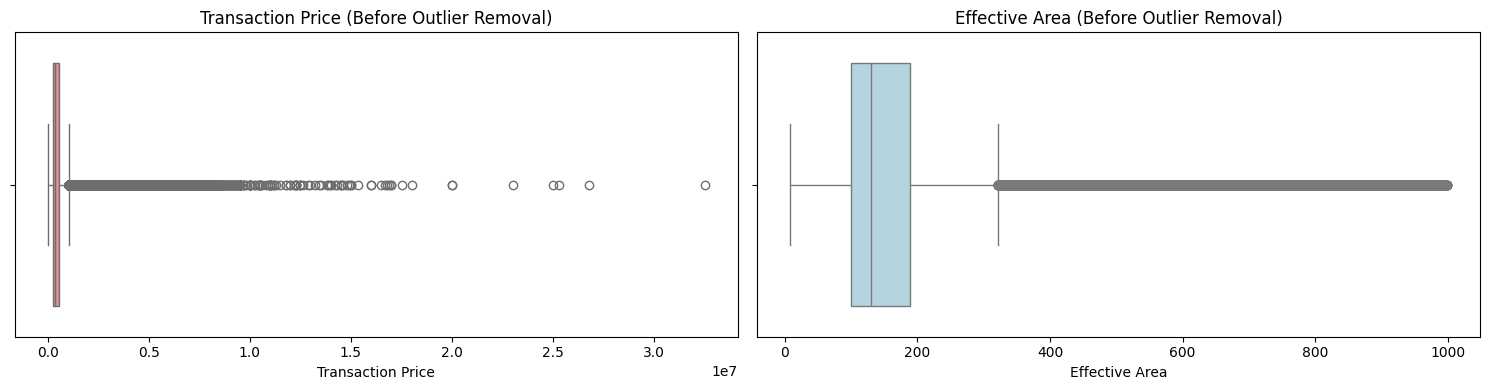

Removed 7162 outlier rows based on statistical thresholds.


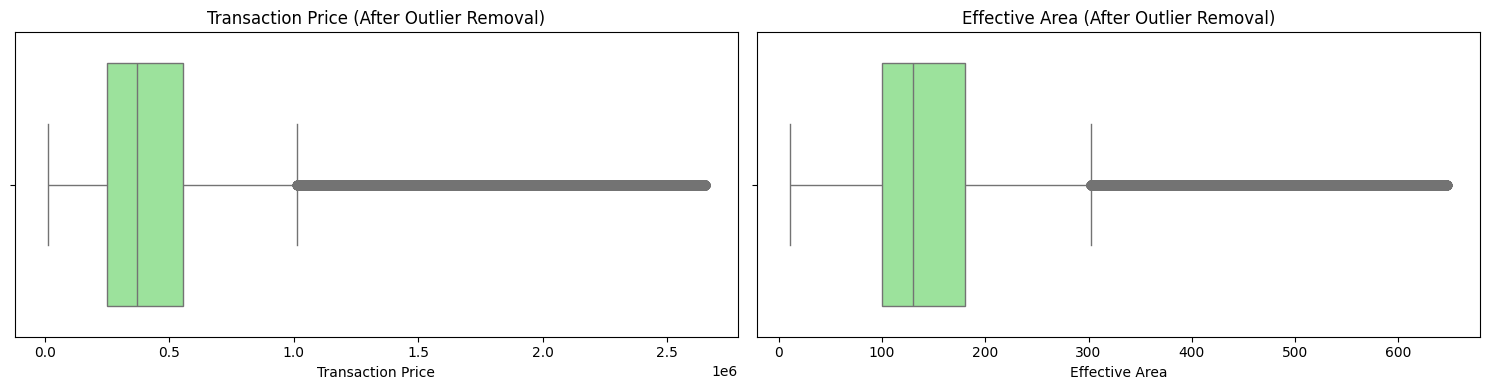

In [18]:
# Visualize BEFORE removing outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(x=df['Transaction Price'], ax=axes[0], color='lightcoral')
axes[0].set_title('Transaction Price (Before Outlier Removal)')
sns.boxplot(x=df['Effective Area'], ax=axes[1], color='lightblue')
axes[1].set_title('Effective Area (Before Outlier Removal)')
plt.tight_layout()
plt.show()

# Define bottom thresholds
MIN_PRICE_THRESHOLD = 10000.00
MIN_AREA_THRESHOLD = 10.0

# Define top thresholds using the 99th percentile (Removes the top 1% of extreme extremes)
MAX_PRICE_THRESHOLD = df['Transaction Price'].quantile(0.99)
MAX_AREA_THRESHOLD = df['Effective Area'].quantile(0.99)

# Apply the filter
rows_before = df.shape[0]
df = df[
    (df['Transaction Price'] >= MIN_PRICE_THRESHOLD) & (df['Transaction Price'] <= MAX_PRICE_THRESHOLD) &
    (df['Effective Area'] >= MIN_AREA_THRESHOLD) & (df['Effective Area'] <= MAX_AREA_THRESHOLD)
]

print(f"Removed {rows_before - df.shape[0]} outlier rows based on statistical thresholds.")

# Visualize AFTER removing outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(x=df['Transaction Price'], ax=axes[0], color='lightgreen')
axes[0].set_title('Transaction Price (After Outlier Removal)')
sns.boxplot(x=df['Effective Area'], ax=axes[1], color='lightgreen')
axes[1].set_title('Effective Area (After Outlier Removal)')
plt.tight_layout()
plt.show()

:**Dropping unnecessary columns & Standardizing**



In [19]:
cols_to_drop = ['Scheme Name/Area', 'Road Name']
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Dropped columns: {cols_to_drop}")

# Standardize Text Columns (Uppercase and strip spaces to ensure data consistency)
cat_cols = ['Property Type', 'District', 'Mukim', 'Tenure', 'Land Area Unit', 'Floor Area Unit']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

# Reset the index after all the row dropping
df = df.reset_index(drop=True)

print("\n=== Final Cleaned Dataset Info ===")
df.info()

print("\nFinal Dataset Shape:", df.shape)

print("\n=== Missing Values After Cleaning ===")
print(df.isnull().sum())

Dropped columns: ['Scheme Name/Area', 'Road Name']

=== Final Cleaned Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403291 entries, 0 to 403290
Data columns (total 15 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Property Type                    403291 non-null  object        
 1   District                         403291 non-null  object        
 2   Mukim                            403291 non-null  object        
 3   Month, Year of Transaction Date  403291 non-null  datetime64[ns]
 4   Tenure                           403291 non-null  object        
 5   Land/Parcel Area                 402442 non-null  float64       
 6   Land Area Unit                   403291 non-null  object        
 7   Main Floor Area                  297839 non-null  float64       
 8   Floor Area Unit                  403291 non-null  object        
 9   Unit Level                 

Although missing values remain in the Land/Parcel Area and Main Floor Area columns, this is expected due to the nature of the dataset. Landed properties typically contain land area information, while strata properties contain floor area information.

To address this, a new feature, Effective Area, was created to consolidate both measurements into a single unified attribute. This column contains no missing values and is used for subsequent analysis.

Therefore, the remaining missing values in the original area columns do not negatively impact the analysis and are considered acceptable.

**Export Cleaned Dataset**

In [20]:
# Save to your Google Drive to use for Section 3.0
df.to_csv('/content/drive/MyDrive/IDS Project/Dataset/Cleaned_Property.csv', index=False)

# 3.0 Exploratory Data Analysis

**Converting unit to sqft and creating new feature price_per_sqft**

In [21]:
# Convert SQ.M → SQFT
conversion_factor = 10.7639

df['Land/Parcel Area (sqft)'] = df['Land/Parcel Area'] * conversion_factor
df['Main Floor Area (sqft)'] = df['Main Floor Area'] * conversion_factor
df['Effective Area (sqft)'] = df['Effective Area'] * conversion_factor

# Price per sqft
df['price_per_sqft'] = df['Transaction Price'] / df['Effective Area (sqft)']

# Rounding
df['Land/Parcel Area (sqft)'] = df['Land/Parcel Area (sqft)'].round(1)
df['Main Floor Area (sqft)'] = df['Main Floor Area (sqft)'].round(1)
df['Effective Area (sqft)'] = df['Effective Area (sqft)'].round(1)
df['price_per_sqft'] = df['price_per_sqft'].round(2)

**Drop unnecessary columns**

In [22]:
df = df.drop(columns=[
    'Land Area Unit',
    'Floor Area Unit'
])

**Rename columns**

In [23]:
df = df.rename(columns={
    'Land/Parcel Area': 'Land/Parcel Area (sqm)',
    'Main Floor Area': 'Main Floor Area (sqm)',
    'Effective Area': 'Effective Area (sqm)'
})

In [24]:
df.head()

,Property Type,District,Mukim,"Month, Year of Transaction Date",Tenure,Land/Parcel Area (sqm),Main Floor Area (sqm),Unit Level,Transaction Price,Property Category,Effective Area (sqm),Transaction Year,Transaction Month,Land/Parcel Area (sqft),Main Floor Area (sqft),Effective Area (sqft),price_per_sqft
0,1 - 1 1/2 STOREY SEMI-DETACHED,ALOR GAJAH,BDR MASJID TANAH,2024-03-01,FREEHOLD,374.0,106.0,0.0,470000.0,LANDED,374.0,2024,3,4025.7,1141.0,4025.7,116.75
1,1 - 1 1/2 STOREY SEMI-DETACHED,ALOR GAJAH,BELIMBING,2023-05-01,LEASEHOLD,234.0,67.0,0.0,483000.0,LANDED,234.0,2023,5,2518.8,721.2,2518.8,191.76
2,1 - 1 1/2 STOREY SEMI-DETACHED,ALOR GAJAH,BELIMBING,2021-04-01,FREEHOLD,268.0,118.0,0.0,359000.0,LANDED,268.0,2021,4,2884.7,1270.1,2884.7,124.45
3,1 - 1 1/2 STOREY SEMI-DETACHED,ALOR GAJAH,BELIMBING,2021-04-01,FREEHOLD,268.0,118.0,0.0,435000.0,LANDED,268.0,2021,4,2884.7,1270.1,2884.7,150.79
4,1 - 1 1/2 STOREY SEMI-DETACHED,ALOR GAJAH,BELIMBING,2021-04-01,FREEHOLD,297.0,118.0,0.0,373000.0,LANDED,297.0,2021,4,3196.9,1270.1,3196.9,116.68


**Property Type Popularity (Bar Chart)**

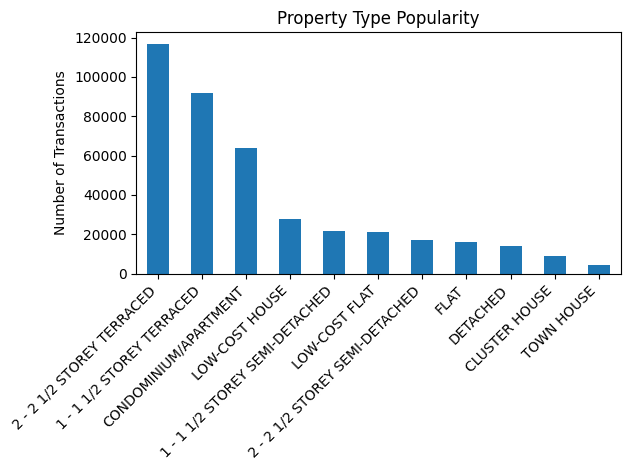

In [25]:
df['Property Type'].value_counts().sort_values(ascending=False).plot(kind='bar')
plt.title('Property Type Popularity')
plt.xlabel('')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This bar chart shows the number of transactions for each property type. Terrace houses clearly dominate the market, with 2–2½ storey and 1–1½ storey terraced properties recording the highest transaction volumes, indicating strong buyer demand in this segment. In contrast, property types such as cluster houses, townhouses, and detached houses have noticeably fewer transactions, which may suggest higher prices, limited supply, or more niche demand. Overall, the trend highlights a preference for relatively more affordable and widely available housing options.

**Tenure Distribution (Bar Chart）**

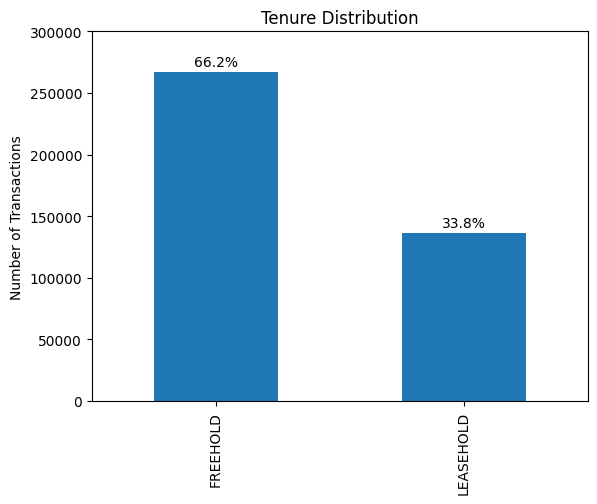

In [26]:
counts = df['Tenure'].value_counts()
percentages = df['Tenure'].value_counts(normalize=True) * 100

ax = counts.plot(kind='bar')

# Add percentage labels on top of bars
for i, (count, pct) in enumerate(zip(counts, percentages)):
    ax.text(i, count + 5000, f'{pct:.1f}%', ha='center')

plt.title('Tenure Distribution')
plt.xlabel('')
plt.ylabel('Number of Transactions')
plt.ylim(0,300000)
plt.show()

This bar chart shows the distribution of property tenure. Freehold properties clearly dominate the market, with significantly higher transaction volumes compared to leasehold properties. Freehold accounts for approximately 66.2% of total transactions, while leasehold represents around 33.8%. This suggests a strong buyer preference for properties with permanent ownership, possibly due to their long-term investment value and greater ownership security.

**Unit Level Distribution (Histogram)**

In [27]:
high_rise = df[df['Property Category'].isin([
    'STRATA'
])]

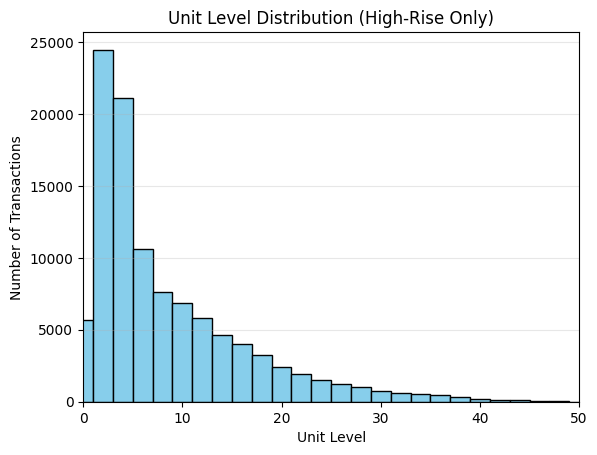

In [28]:
high_rise['Unit Level'].plot(
    kind='hist',
    bins=30,
    color='skyblue',
    edgecolor='black'
)

plt.xlim(0, 50)
plt.title('Unit Level Distribution (High-Rise Only)')
plt.xlabel('Unit Level')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', alpha=0.3)
plt.show()

After filtering out landed properties, the unit level distribution for high-rise properties exhibits a clear right-skewed pattern. Most transactions are concentrated in lower-floor units, while higher-floor units show significantly lower transaction volumes. This may suggest that lower-floor units are more affordable or widely available, whereas higher-floor units are either limited in supply or cater to a more niche market segment.

**Price Distribution (Histogram with KDE)**

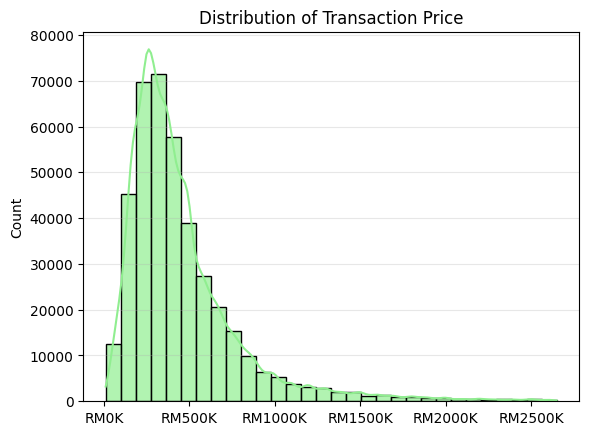

In [29]:
sns.histplot(df['Transaction Price'], bins=30, kde=True, color='lightgreen', edgecolor='black', alpha=0.7)

ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'RM{int(x/1000)}K'))

plt.xlabel('')
plt.ylabel('Count')
plt.title('Distribution of Transaction Price')
plt.grid(axis='y', alpha=0.3)

The distribution of transaction prices is highly right-skewed, with a large concentration of properties in the lower price range and a noticeable spike on the left side of the histogram. Most transactions fall within the lower to mid-price range, while a small number of high-priced properties create a long tail extending towards the right. This indicates that the data is not normally distributed and is heavily influenced by extreme values.

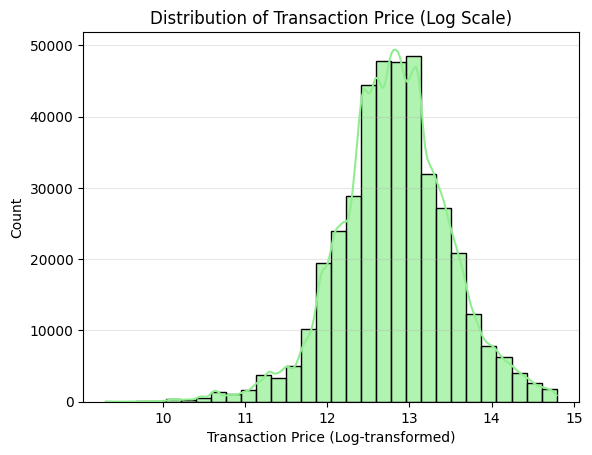

In [30]:
sns.histplot(np.log1p(df['Transaction Price']), bins=30, kde=True,
             color='lightgreen', edgecolor='black', alpha=0.7)

plt.xlabel('Transaction Price (Log-transformed)')
plt.ylabel('Count')
plt.title('Distribution of Transaction Price (Log Scale)')
plt.grid(axis='y', alpha=0.3)

plt.show()

After applying a log transformation, the distribution becomes more symmetric and evenly spread across the range. The transformation reduces the impact of extreme high values while expanding the lower-value range, making the overall pattern clearer. The resulting shape suggests that transaction prices follow a log-normal distribution, which is more appropriate for analysis and interpretation in this context.

**Price vs. Property Type (Boxplot)**

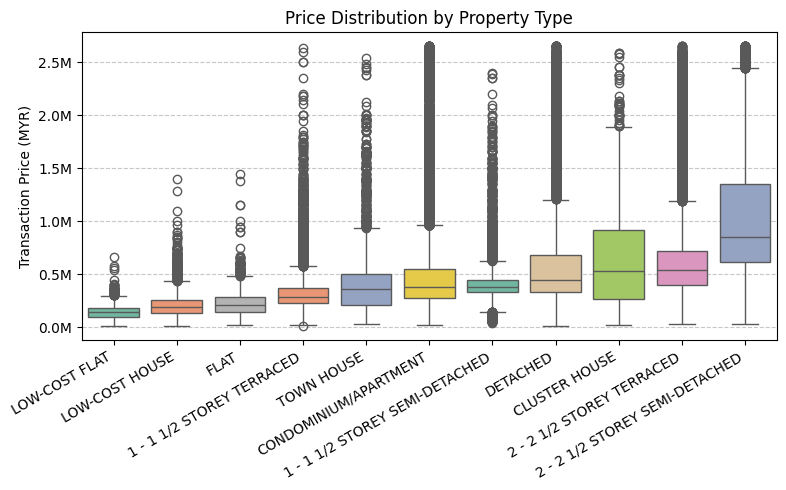

In [31]:
plt.figure(figsize=(8,5))

order = df.groupby('Property Type')['Transaction Price'].median().sort_values().index

sns.boxplot(
    x='Property Type',
    y='Transaction Price',
    data=df,
    order=order,
    palette='Set2',
    hue='Property Type'
)

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.title("Price Distribution by Property Type")
plt.xlabel("")
plt.ylabel("Transaction Price (MYR)")

plt.xticks(rotation=30, ha='right')
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

This boxplot shows a clear relationship between property type and price, with low-cost flats and houses at the bottom end featuring the lowest and most tightly clustered prices, followed by mid-range properties like flats, terraced houses, townhouses, and condominiums that exhibit moderate price levels but increasing variability. High-end property types such as detached, cluster houses, and especially 2–2½ storey semi-detached homes command the highest median prices and display the widest spreads, indicating significant variation driven by factors like size, location, and luxury features. Notably, condominiums and apartments also show a broad distribution with many high-value outliers, suggesting that while they are generally mid-range, premium units in desirable areas can reach prices comparable to landed properties.

**Effective Area vs. Price (Scatter Plot)**

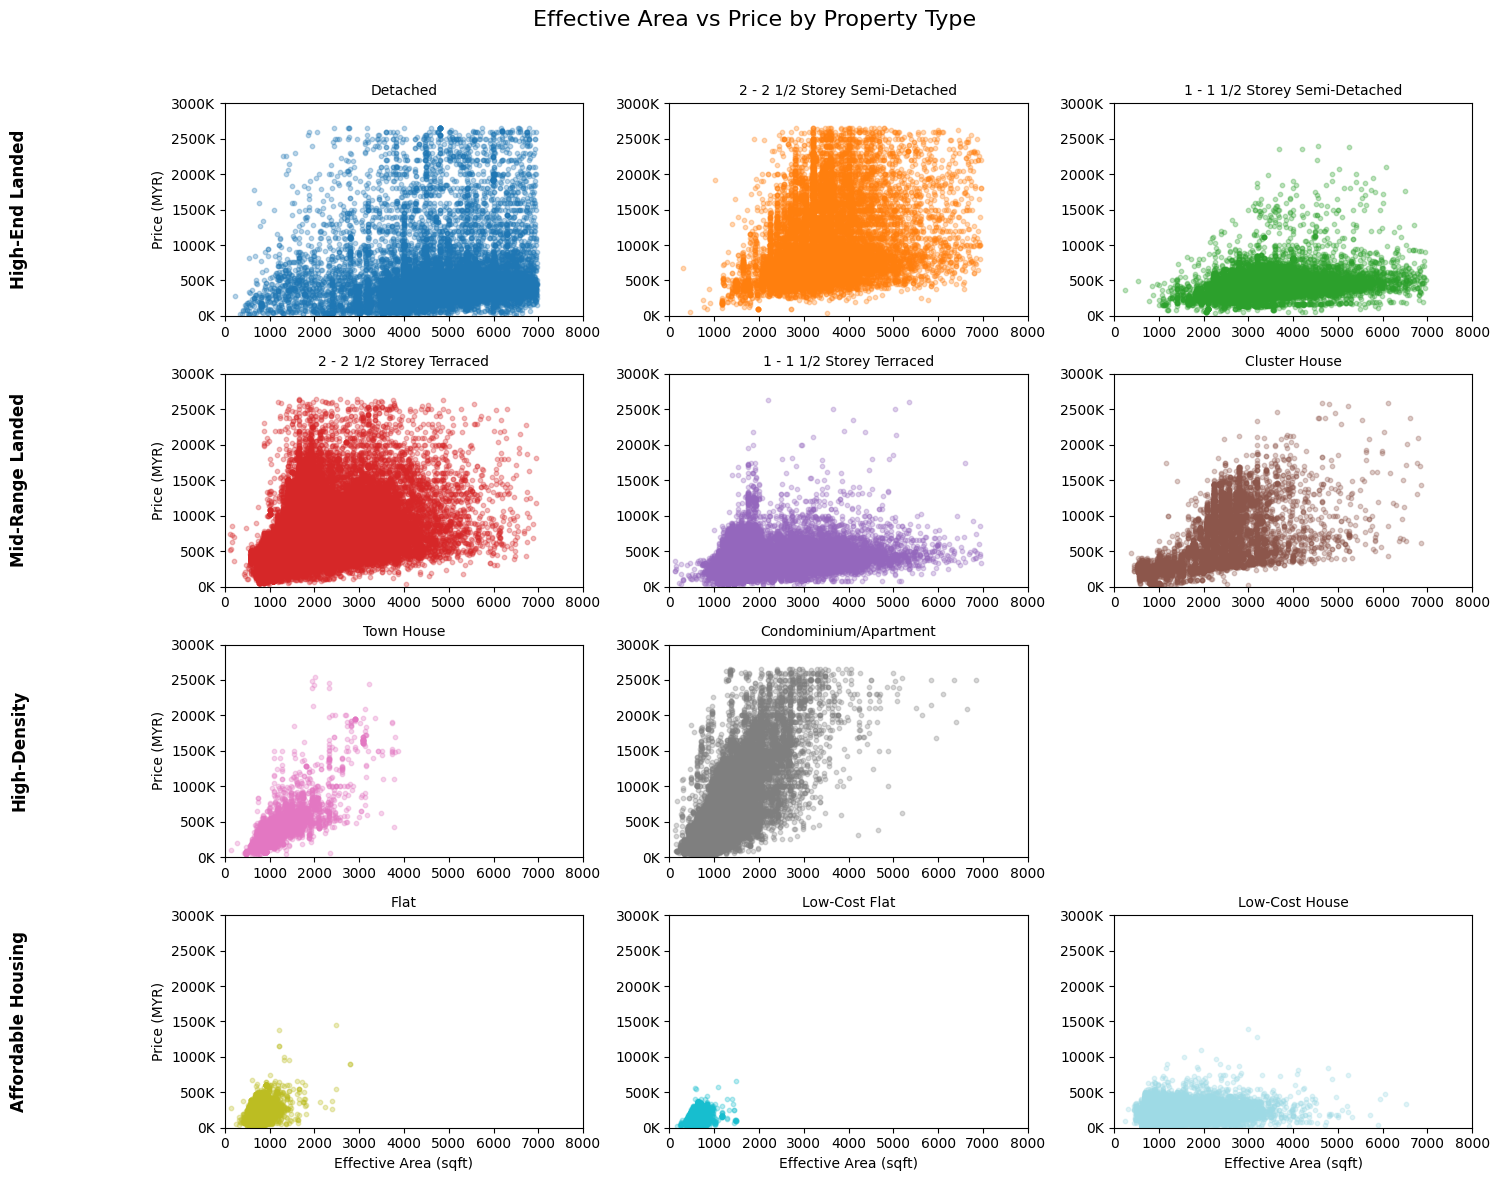

In [32]:
# Define grouped types
groups = [
    ['DETACHED', '2 - 2 1/2 STOREY SEMI-DETACHED', '1 - 1 1/2 STOREY SEMI-DETACHED'],
    ['2 - 2 1/2 STOREY TERRACED', '1 - 1 1/2 STOREY TERRACED', 'CLUSTER HOUSE'],
    ['TOWN HOUSE', 'CONDOMINIUM/APARTMENT'],  # only 2 → one empty slot
    ['FLAT', 'LOW-COST FLAT', 'LOW-COST HOUSE']
]

group_titles = [
    'High-End Landed',
    'Mid-Range Landed',
    'High-Density',
    'Affordable Housing'
]

# Flatten for color mapping
types = [t for group in groups for t in group if t in df['Property Type'].unique()]
num_types = len(types)

colors = mpl.colormaps.get_cmap('tab20').resampled(num_types)

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.reshape(4, 3)

color_idx = 0

for row in range(4):
    for col in range(3):
        ax = axes[row, col]

        # If this position has a type
        if col < len(groups[row]) and groups[row][col] in df['Property Type'].unique():
            ptype = groups[row][col]
            subset = df[df['Property Type'] == ptype]

            ax.scatter(
                subset['Effective Area (sqft)'],
                subset['Transaction Price'],
                color=colors(color_idx),
                alpha=0.3,
                s=10
            )

            ax.set_title(ptype.title(), fontsize=10)
            color_idx += 1

        else:
            fig.delaxes(ax)
            continue

        # X label (only last row)
        if row == 3:
            ax.set_xlabel('Effective Area (sqft)')
        else:
            ax.set_xlabel('')

        # Y label (only first column)
        if col == 0:
            ax.set_ylabel('Price (MYR)')
        else:
            ax.set_yticklabels([])

        # Format y-axis
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K')
        )

        ax.set_xlim(0, 8000)
        ax.set_ylim(0, 3000000)

    # Add row title (group label)
    axes[row, 0].annotate(
        group_titles[row],
        xy=(-0.6, 0.5),
        xycoords='axes fraction',
        fontsize=12,
        fontweight='bold',
        rotation=90,
        va='center'
    )

plt.suptitle('Effective Area vs Price by Property Type', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

There is a clear positive relationship between effective area and property price, with larger properties generally costing more. High-end property types such as detached and semi-detached houses show greater price variation, indicating that factors beyond size also influence value. Mid-range properties like terraced and cluster houses exhibit more consistent pricing patterns. In contrast, flats and low-cost housing are tightly clustered at smaller sizes and lower prices, reflecting affordability constraints.

**Transaction Volume Timeline (Line Chart)**

In [33]:
monthly_total = df.groupby('Transaction Month')['Transaction Price'].sum()
monthly_total = monthly_total.reset_index()
monthly_total

,Transaction Month,Transaction Price
0,1,1.324666e+10
1,2,1.186362e+10
2,3,1.469789e+10
3,4,1.639928e+10
4,5,1.631470e+10
5,6,1.492217e+10
6,7,1.779501e+10
7,8,1.677337e+10
8,9,1.456687e+10
9,10,1.657988e+10


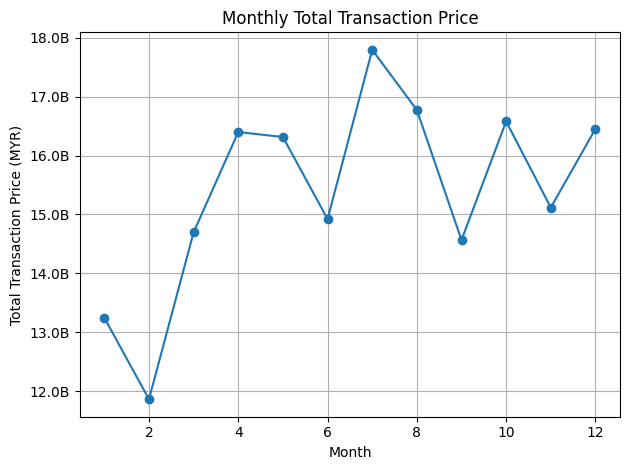

In [34]:
plt.plot(monthly_total['Transaction Month'], monthly_total['Transaction Price'], marker='o')

plt.gca().get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B')
)

plt.title('Monthly Total Transaction Price')
plt.xlabel('Month')
plt.ylabel('Total Transaction Price (MYR)')
plt.grid(True)
plt.tight_layout()
plt.show()

The monthly total transaction price shows fluctuating market activity, ranging from around 12B to 18B. Peaks occur in July, April, and October, indicating high transaction periods, while February and September are comparatively slower, reflecting seasonal trends and giving a clear view of overall market behavior.

**Median Price per Square Foot Over Time (Line Chart)**

In [35]:
median_price_per_year = df.groupby('Transaction Year')['price_per_sqft'].median()
median_price_per_year

,price_per_sqft
Transaction Year,
2021,257.15
2022,250.69
2023,264.42
2024,260.96
2025,248.63


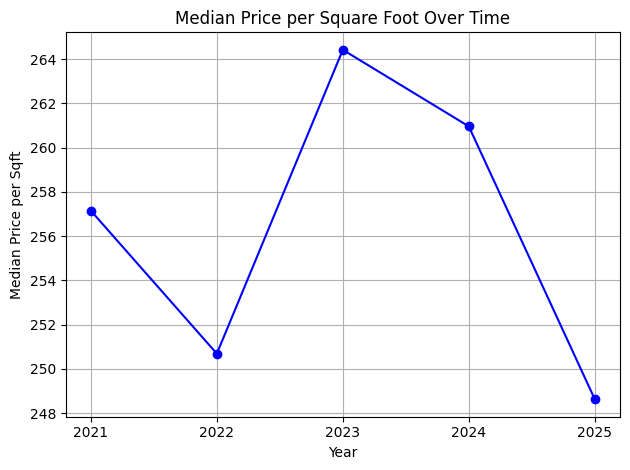

In [36]:
plt.plot(median_price_per_year.index, median_price_per_year.values, marker='o', color='blue')
plt.title('Median Price per Square Foot Over Time')
plt.xlabel('Year')
plt.ylabel('Median Price per Sqft')
plt.xticks(median_price_per_year.index)
plt.grid(True)
plt.tight_layout()
plt.show()

The line chart shows that median price per square foot fluctuated over the five-year period rather than following a steady trend. It declined from around 257 in 2021 to about 251 in 2022, before rising sharply to a peak of approximately 264 in 2023. After this peak, prices slightly decreased to around 261 in 2024 and then dropped more noticeably to about 249 in 2025, marking the lowest point in the period. Overall, the data suggests a temporary surge in 2023 followed by a downward correction, indicating possible market volatility or changing demand conditions in recent years.

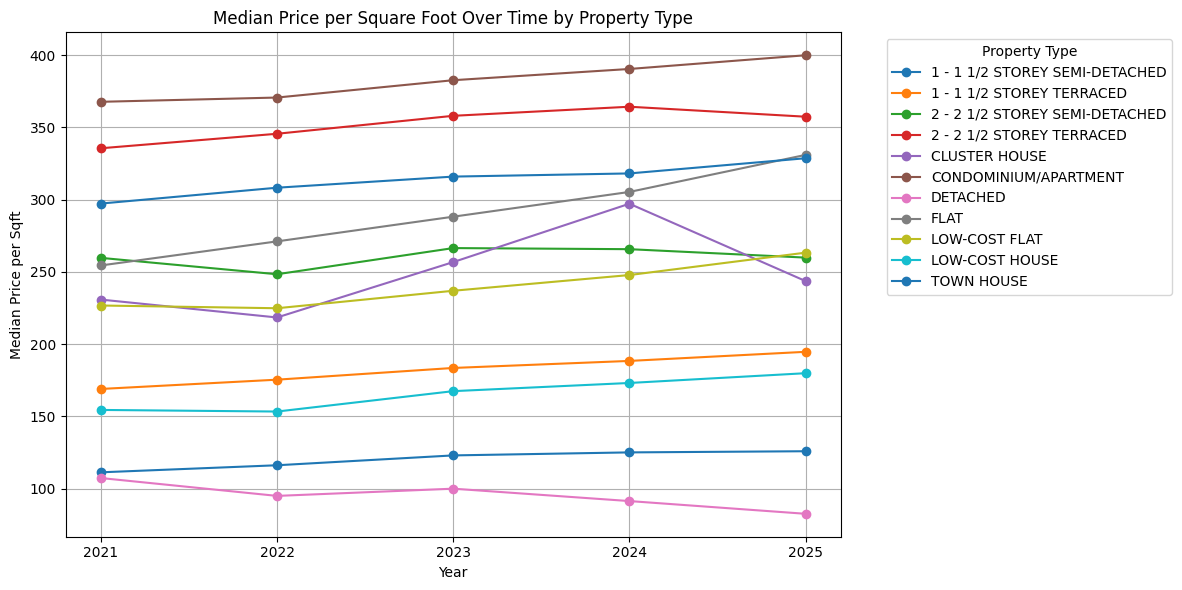

In [37]:
property_types = df['Property Type'].unique()


plt.figure(figsize=(12,6))

for ptype in property_types:
    df_ptype = df[df['Property Type'] == ptype]
    median_price_per_year = df_ptype.groupby('Transaction Year')['price_per_sqft'].median()
    plt.plot(median_price_per_year.index, median_price_per_year.values, marker='o', label=ptype)

plt.title('Median Price per Square Foot Over Time by Property Type')
plt.xlabel('Year')
plt.ylabel('Median Price per Sqft')
plt.grid(True)
plt.xticks(sorted(df['Transaction Year'].unique()))
plt.legend(title='Property Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The line chart illustrates that median price per square foot generally increased across most property types from 2021 to 2025, although trends vary by category. Condominiums/apartments consistently recorded the highest prices and showed steady growth throughout the period, followed by 2–2½ storey terraced houses, which also maintained relatively high and gradually rising values. Flats and townhouses experienced notable upward trends, particularly flats, which showed strong growth toward 2025. In contrast, cluster houses exhibited more volatility, rising sharply to a peak around 2024 before dropping significantly in 2025. Lower-priced segments such as low-cost houses and terraced houses showed moderate but consistent increases, while detached houses were the only category to show a clear overall decline, decreasing steadily after a slight fluctuation. Overall, the data suggests a broad upward movement in property prices with some variation in stability and growth patterns across different property types.

**Top 10 Most Active Districts (Horizontal Bar Chart)**

In [38]:
districts = df.groupby('District')['Transaction Price'].sum()
districts.sort_values(ascending=False, inplace=True)
top_10_act_districts = districts.head(10)
top_10_act_districts

,Transaction Price
District,
JOHOR BAHRU,2.515872e+10
PETALING,2.132212e+10
KUALA LUMPUR,1.690930e+10
HULU LANGAT,1.172063e+10
KLANG,9.865442e+09
SEREMBAN,7.028450e+09
KINTA,6.354695e+09
GOMBAK,6.308080e+09
TIMUR LAUT,6.028033e+09


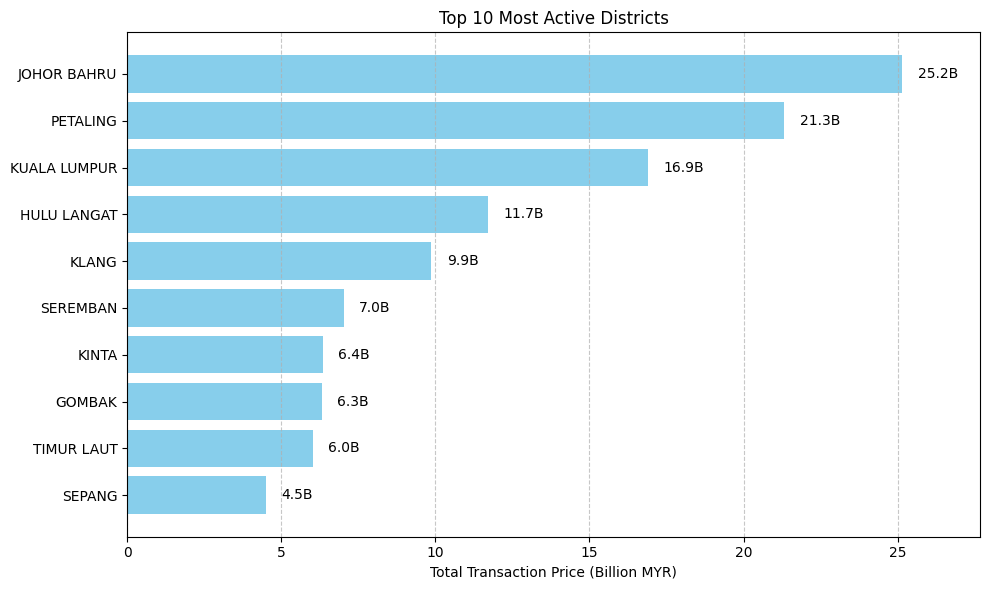

In [39]:
districts_names = top_10_act_districts.index[::-1]
districts_values = top_10_act_districts.values[::-1] / 1e9

plt.figure(figsize=(10,6))
bars = plt.barh(districts_names, districts_values, color='skyblue')
plt.xlabel('Total Transaction Price (Billion MYR)')
plt.title('Top 10 Most Active Districts')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}B', va='center', fontsize=10)

plt.xlim(0, max(districts_values)*1.1)
plt.tight_layout()
plt.show()

The horizontal bar chart shows that property transaction activity is highly concentrated in a few key districts, with Johor Bahru leading significantly at 25.2 billion MYR, followed by Petaling (21.3B) and Kuala Lumpur (16.9B). This suggests strong economic and real estate demand in major urban and border areas, likely driven by population density, commercial activity, and investment interest. Mid-tier districts like Hulu Langat and Klang still contribute substantially but at a noticeably lower level, indicating secondary growth zones. Meanwhile, districts such as Seremban, Kinta, Gombak, Timur Laut, and Sepang fall into a lower activity group, each below 7B MYR, highlighting a long tail where transaction volumes are more modest. Overall, the distribution reflects a clear urban-centric pattern, where a few hotspots dominate the market while the rest show gradual but smaller-scale activity.

**Top 10 Most Expensive Districts (Horizontal Bar Chart)**

In [40]:
disticts_median_price= df.groupby('District')['Transaction Price'].median()
top_10_exp_districts = disticts_median_price.sort_values(ascending = False).head(10)
top_10_exp_districts

,Transaction Price
District,
PUTRAJAYA,676000.0
SEPANG,555000.0
KUALA LUMPUR,520000.0
PETALING,520000.0
JOHOR BAHRU,496000.0
BARAT DAYA,490000.0
KOTA KINABALU,480000.0
BAHAGIAN BINTULU,460000.0
KLANG,450000.0


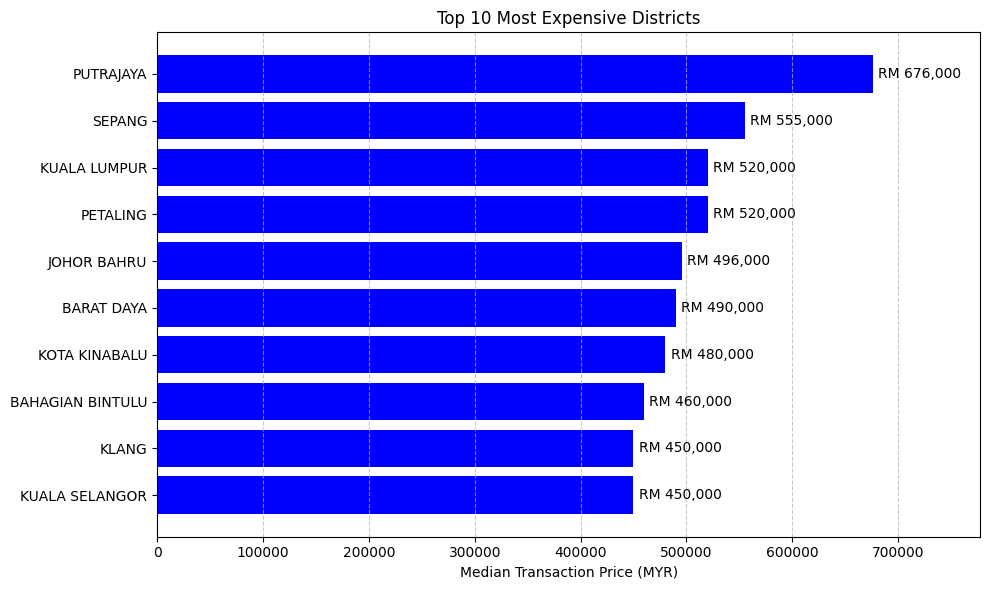

In [41]:
dist_names = top_10_exp_districts.index[::-1]
dist_median_price = top_10_exp_districts.values[::-1]

plt.figure(figsize=(10,6))
bars = plt.barh(dist_names, dist_median_price, color='blue')

plt.xlabel('Median Transaction Price (MYR)')
plt.ylabel('')
plt.title('Top 10 Most Expensive Districts')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5000, bar.get_y() + bar.get_height()/2, f'RM {width:,.0f}', va='center')

plt.xlim(0, max(dist_median_price)*1.15)
plt.tight_layout()
plt.show()

The horizontal bar chart shows that property prices are heavily concentrated in a few premium districts, with Putrajaya standing out as the most expensive by a clear margin (RM 676,000), signaling strong demand for planned urban living and government-linked hubs. This is followed by Sepang and Kuala Lumpur, both benefiting from infrastructure, connectivity, and economic activity. Interestingly, suburban and secondary growth areas like Petaling, Johor Bahru, and Kota Kinabalu also command relatively high prices, reflecting urban spillover and regional development. Meanwhile, districts such as Klang and Kuala Selangor sit at the lower end of the top 10, suggesting they are still comparatively affordable but likely experiencing upward pressure, indicating potential opportunities for future growth or investment.

**Price Heatmap (Correlation Matrix)**

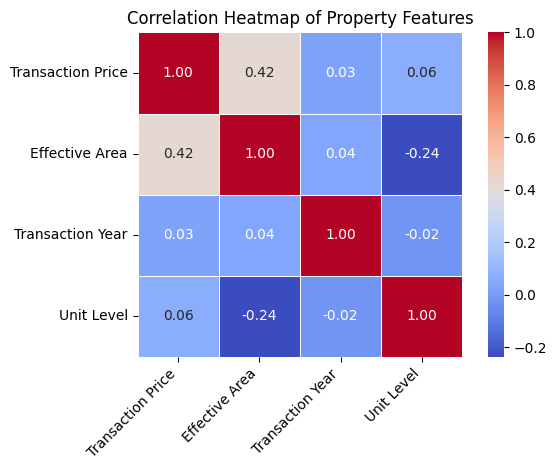

In [42]:
data = df[['Transaction Price', 'Effective Area (sqft)', 'Transaction Year', 'Unit Level']]

data = data.rename(columns={
    'Effective Area (sqft)': 'Effective Area'
})

corr = data.corr()

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5,
            square=True)

plt.title("Correlation Heatmap of Property Features")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The correlation heatmap shows that most property features have weak relationships with each other, except for a moderate positive correlation (0.42) between transaction price and effective area, indicating that larger properties tend to have higher prices. Unit level has a slight negative correlation with effective area (-0.24), suggesting that higher-floor units may be somewhat smaller in size. Meanwhile, transaction year shows almost no correlation with the other variables, implying that time does not significantly influence price, size, or unit level within this dataset. Overall, the results suggest that property size is the most influential factor affecting transaction price, while other variables have minimal impact.

In [43]:
# Save updated data to Google Drive for future use
#df.to_csv('/content/drive/MyDrive/IDS Project/Dataset/Updated_Property.csv', index=False)

Filtering out Kuala Lumpur Data

In [44]:
df_kl = df[df['District'] == 'KUALA LUMPUR']
df_kl.head()
df_kl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24132 entries, 8738 to 401449
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Property Type                    24132 non-null  object        
 1   District                         24132 non-null  object        
 2   Mukim                            24132 non-null  object        
 3   Month, Year of Transaction Date  24132 non-null  datetime64[ns]
 4   Tenure                           24132 non-null  object        
 5   Land/Parcel Area (sqm)           24129 non-null  float64       
 6   Main Floor Area (sqm)            5135 non-null   float64       
 7   Unit Level                       24132 non-null  float64       
 8   Transaction Price                24132 non-null  float64       
 9   Property Category                24132 non-null  object        
 10  Effective Area (sqm)             24132 non-null  float64   

Boxplot of Price per Sqft vs Area

In [45]:
print(df_kl['Mukim'].unique())

['KUALA LUMPUR TOWN CENTRE' 'MUKIM BATU' 'MUKIM KUALA LUMPUR'
 'MUKIM PETALING' 'MUKIM SETAPAK' 'MUKIM AMPANG' 'MUKIM CHERAS'
 'MUKIM ULU KELANG']


/tmp/ipykernel_2162/1695746142.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Mukim', y='price_per_sqft', data=df_kl_top_mukims, order=top_10_mukims, palette='viridis')


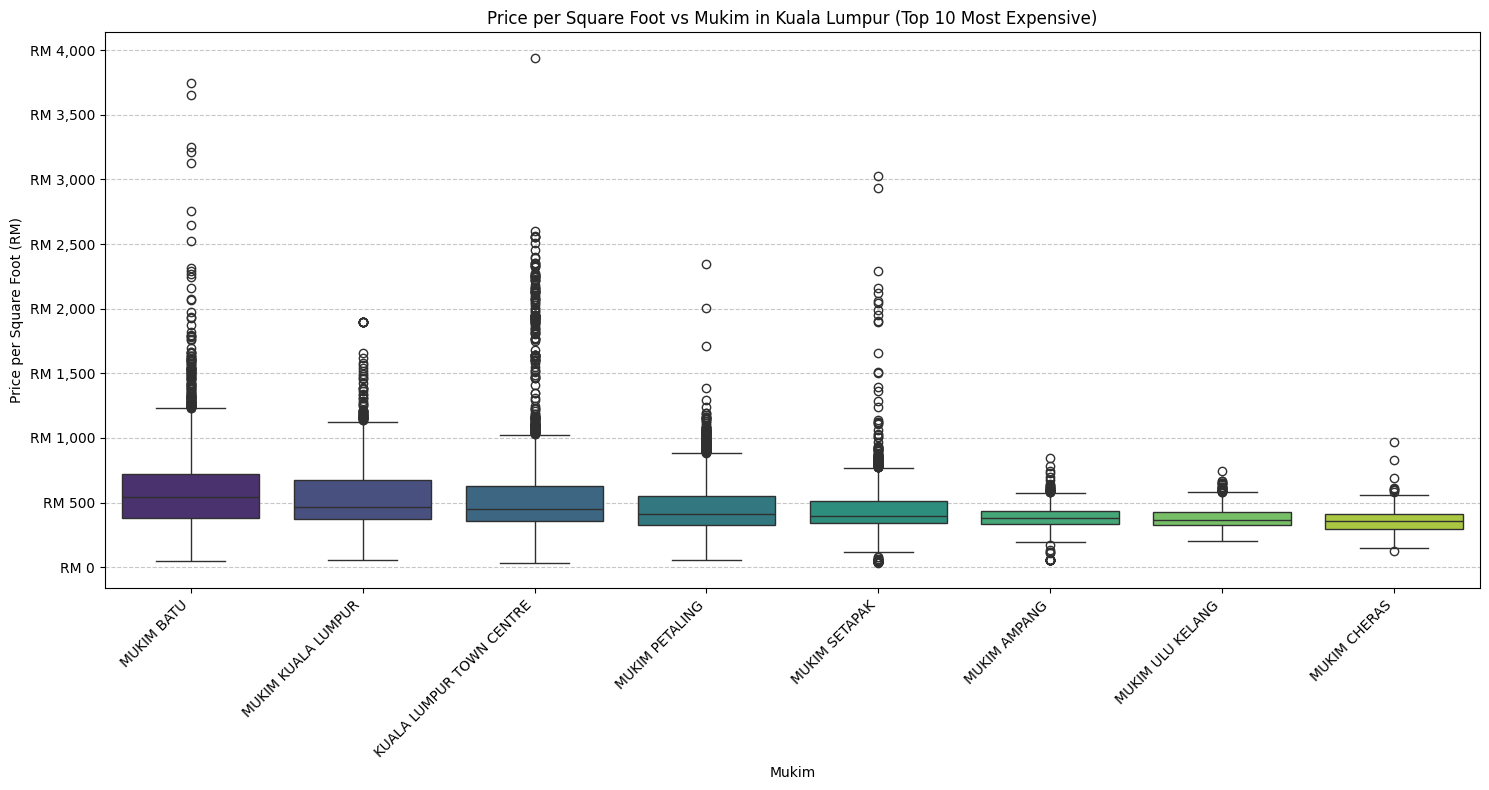

In [46]:
plt.figure(figsize=(15, 8))

# Calculate median price_per_sqft for each mukim in df_kl
median_prices_mukim = df_kl.groupby('Mukim')['price_per_sqft'].median().sort_values(ascending=False)

# Select the top 15 mukims by median price_per_sqft
top_10_mukims = median_prices_mukim.head(10).index.tolist()

# Filter df_kl to include only these top mukims
df_kl_top_mukims = df_kl[df_kl['Mukim'].isin(top_10_mukims)]

# Create the boxplot
sns.boxplot(x='Mukim', y='price_per_sqft', data=df_kl_top_mukims, order=top_10_mukims, palette='viridis')

# Format y-axis to display prices in RM
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'RM {x:,.0f}'))

plt.title('Price per Square Foot vs Mukim in Kuala Lumpur (Top 10 Most Expensive)')
plt.xlabel('Mukim')
plt.ylabel('Price per Square Foot (RM)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Kuala Lumpur In-depth Analysis

Price distribution in Kuala Lumpur

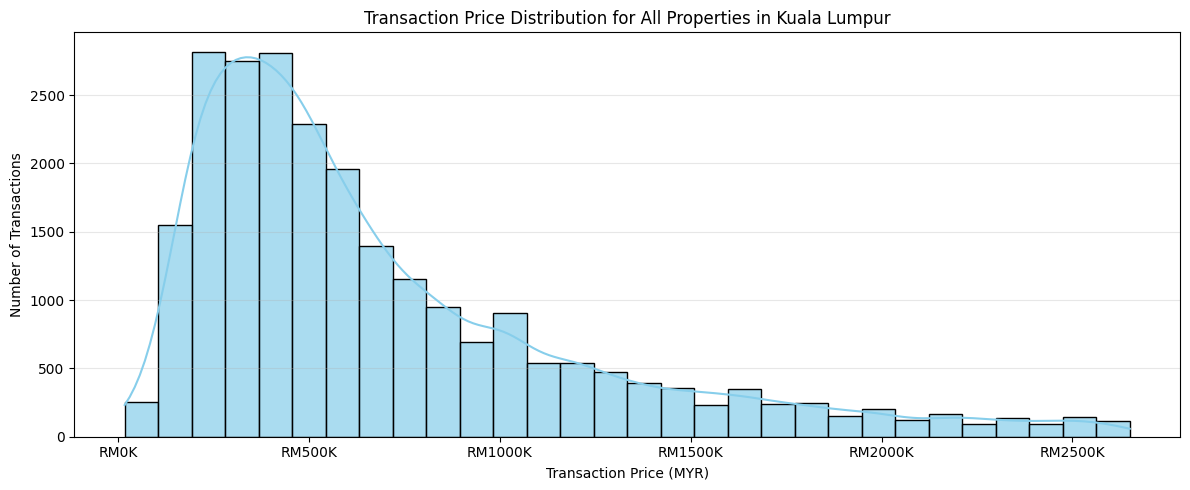

In [47]:
plt.figure(figsize=(12, 5))
sns.histplot(df_kl['Transaction Price'], bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'RM{int(x/1000)}K'))
plt.title('Transaction Price Distribution for All Properties in Kuala Lumpur')
plt.xlabel('Transaction Price (MYR)')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

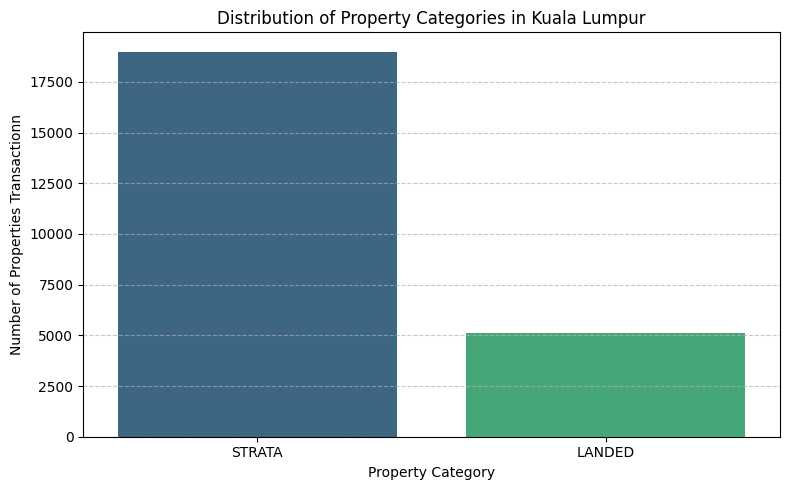

In [48]:
# Calculate the counts of each Property Category in df_kl
category_counts = df_kl['Property Category'].value_counts()

# Create the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, legend=False, palette='viridis')

plt.title('Distribution of Property Categories in Kuala Lumpur')
plt.xlabel('Property Category')
plt.ylabel('Number of Properties Transactionn')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

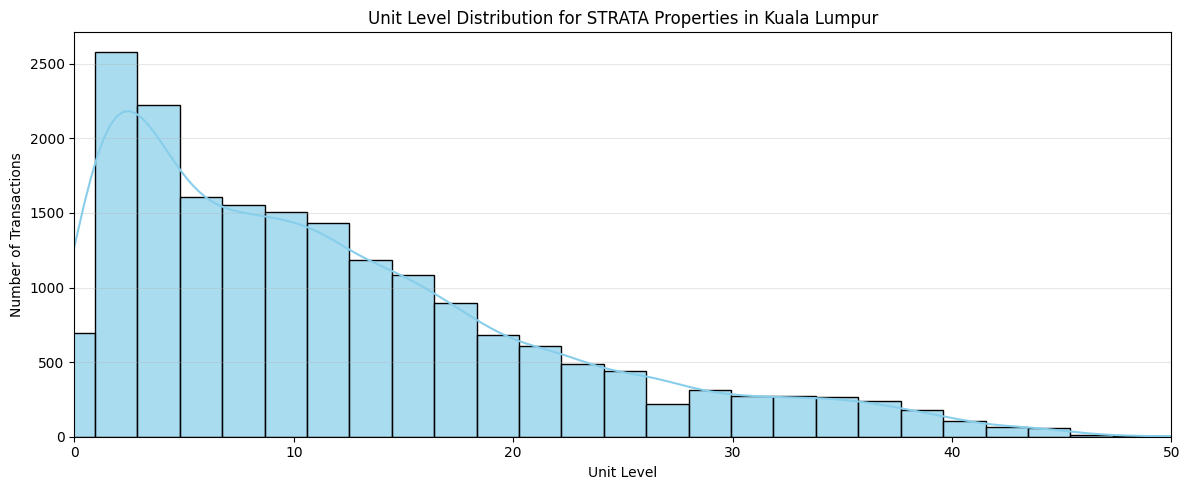

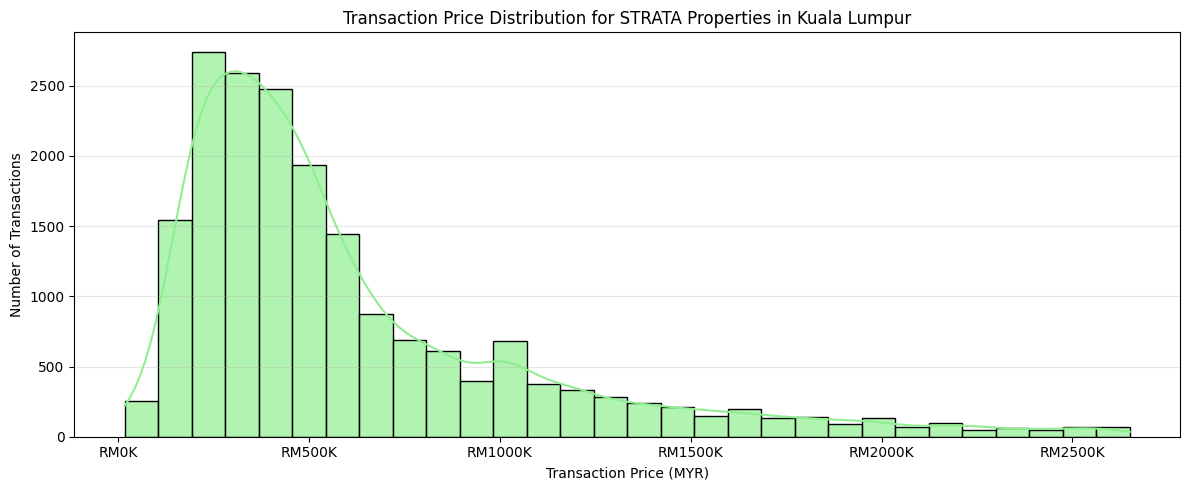

In [49]:
# Filter df_kl for 'STRATA' properties
df_kl_strata = df_kl[df_kl['Property Category'] == 'STRATA']

# Plot histogram of Unit Level for strata properties in KL
plt.figure(figsize=(12, 5))
sns.histplot(df_kl_strata['Unit Level'], bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Unit Level Distribution for STRATA Properties in Kuala Lumpur')
plt.xlabel('Unit Level')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', alpha=0.3)
plt.xlim(0, 50) # Limit x-axis for better visibility, similar to previous plot
plt.tight_layout()
plt.show()

# Plot histogram of Transaction Price for strata properties in KL
plt.figure(figsize=(12, 5))
sns.histplot(df_kl_strata['Transaction Price'], bins=30, kde=True, color='lightgreen', edgecolor='black', alpha=0.7)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'RM{int(x/1000)}K'))
plt.title('Transaction Price Distribution for STRATA Properties in Kuala Lumpur')
plt.xlabel('Transaction Price (MYR)')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

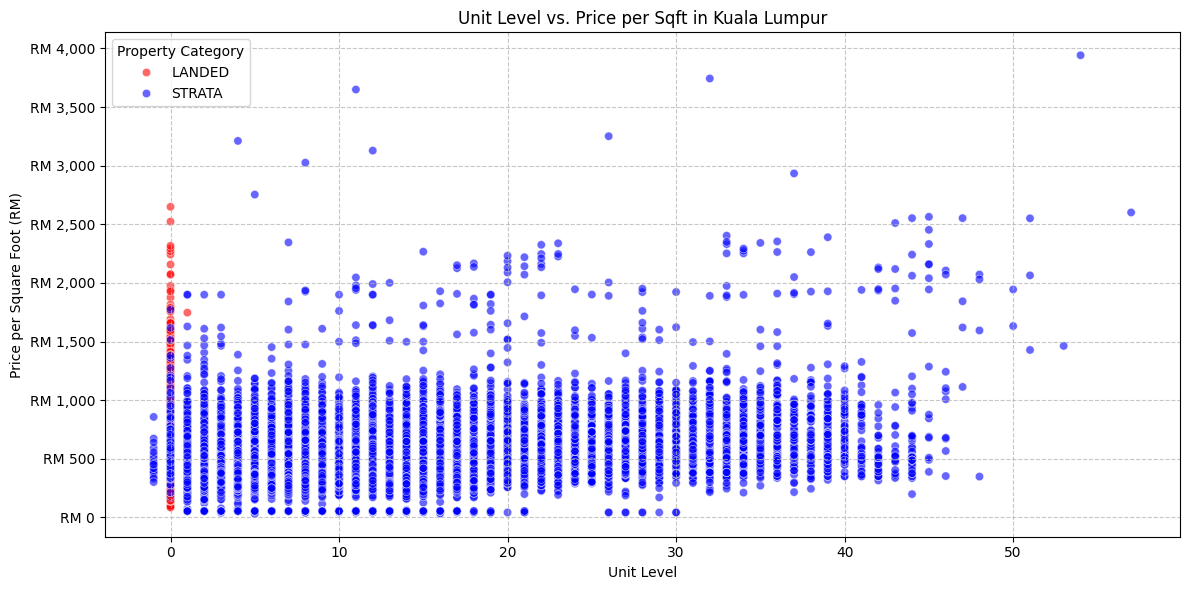

In [50]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Unit Level', y='price_per_sqft', data=df_kl, alpha=0.6, hue='Property Category', palette={'STRATA': 'blue', 'LANDED': 'red'})

# Format y-axis to display prices in RM
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'RM {x:,.0f}'))

plt.title('Unit Level vs. Price per Sqft in Kuala Lumpur')
plt.xlabel('Unit Level')
plt.ylabel('Price per Square Foot (RM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [51]:
# Define the bins and labels for price categorization
bins = [0, 400000, 750000, 1200000, float('inf')]
labels = ['Budget', 'Mid-Range', 'High-End', 'Luxury']

# Apply pd.cut to create the new 'Price Category' column
df_kl_copy = df_kl.copy()
df_kl_copy['Price Category'] = pd.cut(df_kl_copy['Transaction Price'], bins=bins, labels=labels, right=False)

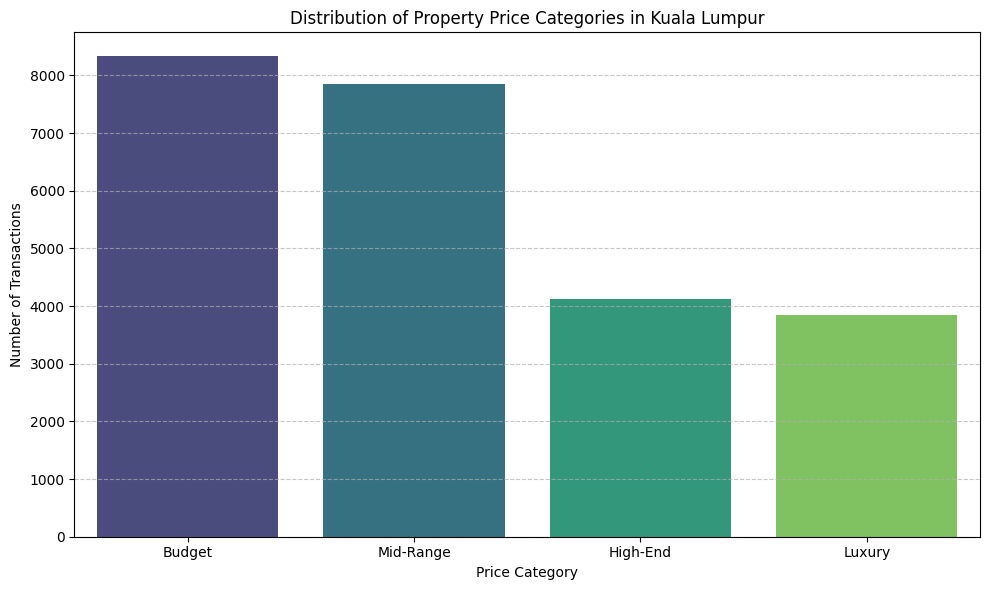

In [52]:
# Create a countplot for the new 'Price Category'
plt.figure(figsize=(10, 6))
sns.countplot(x='Price Category', data=df_kl_copy, order=labels, hue='Price Category', palette='viridis', legend=False)

plt.title('Distribution of Property Price Categories in Kuala Lumpur')
plt.xlabel('Price Category')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


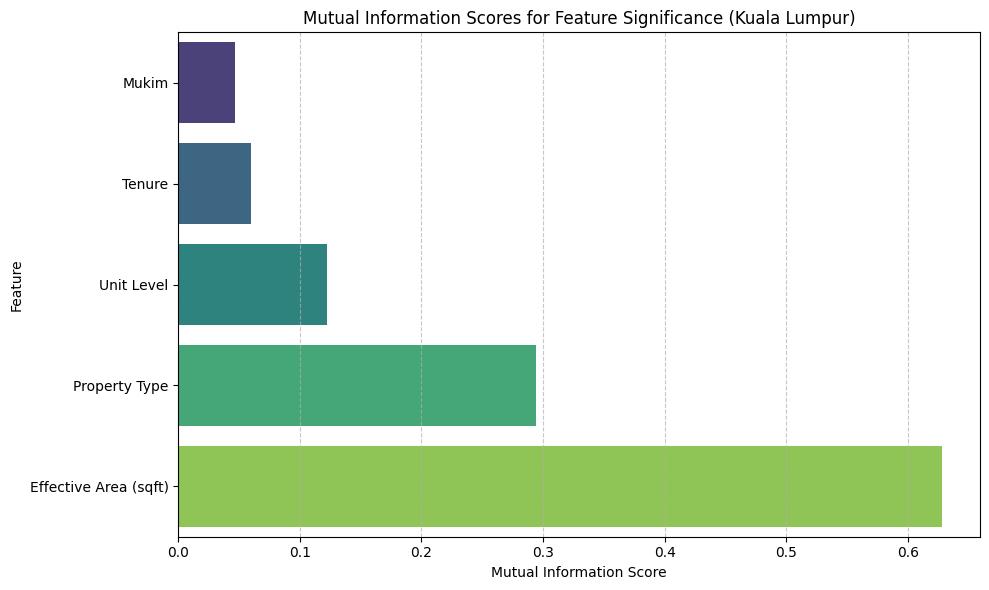

In [53]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import seaborn as sns

# Use df_kl_copy which contains 'Price Category'
# Create a copy to avoid SettingWithCopyWarning for feature engineering steps
df_ml = df_kl_copy.copy()

# Select features
features_to_use = ['Effective Area (sqft)', 'Unit Level', 'Mukim', 'Property Type', 'Tenure']
X = df_ml[features_to_use].copy()
y = df_ml['Price Category']

# Handle categorical features in X by Label Encoding
categorical_features_X = ['Mukim', 'Property Type', 'Tenure']
for col in categorical_features_X:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Encode the target variable y as well
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

# Define which features are discrete for mutual_info_classif
# 'Effective Area (sqft)' and 'Unit Level' can be treated as continuous.
# The encoded categorical features are discrete.
discrete_features_indices = [X.columns.get_loc(col) for col in categorical_features_X if col in X.columns]

mi_scores = mutual_info_classif(X, y_encoded, discrete_features=discrete_features_indices, random_state=42)

# Create a Series for easier plotting
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=True)

# Plotting the horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, hue=mi_series.index, palette='viridis', legend=False) # Resolved FutureWarning
plt.title('Mutual Information Scores for Feature Significance (Kuala Lumpur)')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Export df_kl to csv


In [54]:
df_kl.to_csv('/content/drive/MyDrive/IDS Project/Dataset/KL_Property.csv', index=False)